## Pandas 


This part should provide you with the most basic principles of pandas, which is a quite useful tool in terms of data analysis and manipulation. In general it links with numpy and its array structures and can be combined with other libaries like sklearn.

In [101]:
# as usual we import the pandas package

import pandas as pd
import numpy as np

# 1. Data Structures

The most import data structures/objects in pandas are series and dataframes.

## 1.1 Series 

Series are one dimensional arrays-like objects with a sequence of data with same type and an array of labels, called index.

In [102]:
## 1.1 Series 

obj=pd.Series(["a","b","c","d"])
obj

0    a
1    b
2    c
3    d
dtype: str

In [103]:
# one can use the index to select specific values within the series 
# 
obj[1]

'b'

In [104]:
# its like a dictionary, index and the respective value stay together

1 in obj


True

In [105]:
# its easy to convert a dictionary to a series and vice versa 


data={"Frankfurt":0.7,"Berlin":4,"Hamburg":1.8}
obj3=pd.Series(data)

# note the keys has become the indices 

obj3

Frankfurt    0.7
Berlin       4.0
Hamburg      1.8
dtype: float64

In [106]:
# one can also specify indices explicitly
cities=["London","Paris","Houston"]
obj2=pd.Series(data,index=cities)
obj2

London    NaN
Paris     NaN
Houston   NaN
dtype: float64

In [107]:
# due to the fact that the values are not in the series, "NaN" occurs, i.e., often referred to missing values
# often very useful while analysing data 

pd.isna(obj2)

London     True
Paris      True
Houston    True
dtype: bool

In [108]:
# arithmetic operations of series are index oriented
obj_new=pd.Series({"a":100,"b":4000,"c":400})

obj_multi=2*obj_new
obj_multi

a     200
b    8000
c     800
dtype: int64

## 1.2. DataFrames

DataFrames are tables of data in columns and rows. Imagine having a dictionary of series with same index. 

One can easly create one using a dictionary

In [109]:
data={"state":["Germany","England","India","Spain","USA","China"],
      "temperature":[20,18,30,34,28,33]}
first_frame=pd.DataFrame(data)
first_frame

,state,temperature
0,Germany,20
1,England,18
2,India,30
3,Spain,34
4,USA,28
5,China,33


Note that if you use jupyter, the DataFrame objects are presented as HTML tables

You can access specifc rows and columns in several ways:

In [110]:
#accessing specific columns
first_frame["state"] 

0    Germany
1    England
2      India
3      Spain
4        USA
5      China
Name: state, dtype: str

In [111]:
first_frame.head()
first_frame.tail()

,state,temperature
1,England,18
2,India,30
3,Spain,34
4,USA,28
5,China,33


In [112]:
#accessing specific rows

first_frame.loc[2]

state          India
temperature       30
Name: 2, dtype: object

### 1.2.1 Modification

In [113]:
#adding a column

first_frame["new_column"]=np.arange(6.)
first_frame

,state,temperature,new_column
0,Germany,20,0.0
1,England,18,1.0
2,India,30,2.0
3,Spain,34,3.0
4,USA,28,4.0
5,China,33,5.0


In [114]:
# or adding again series 

wind=pd.Series([10,15,4,20,30])
first_frame["wind"]=wind
first_frame
#missing values will be filled by NaN

,state,temperature,new_column,wind
0,Germany,20,0.0,10.0
1,England,18,1.0,15.0
2,India,30,2.0,4.0
3,Spain,34,3.0,20.0
4,USA,28,4.0,30.0
5,China,33,5.0,NaN


In [115]:
#point notation

first_frame["high wind"]=first_frame["wind"]>=10
first_frame

,state,temperature,new_column,wind,high wind
0,Germany,20,0.0,10.0,True
1,England,18,1.0,15.0,True
2,India,30,2.0,4.0,False
3,Spain,34,3.0,20.0,True
4,USA,28,4.0,30.0,True
5,China,33,5.0,NaN,False


In [116]:
# column delete

del first_frame["new_column"]


In [117]:
first_frame

,state,temperature,wind,high wind
0,Germany,20,10.0,True
1,England,18,15.0,True
2,India,30,4.0,False
3,Spain,34,20.0,True
4,USA,28,30.0,True
5,China,33,NaN,False


## 2. General Functionalities of pandas-objects

### 2.1 Re-indexing-Function



In [118]:
###re-indexing series 

obj=pd.Series([-1,-2,1,3,1],index=["c","d","e","f","a"])
obj

c   -1
d   -2
e    1
f    3
a    1
dtype: int64

In [119]:
obj_2=obj.reindex(["a","b","c","d","e"])
obj_2

a    1.0
b    NaN
c   -1.0
d   -2.0
e    1.0
dtype: float64

In [120]:
#re-indexing DataFrames

frame=pd.DataFrame({"names":["Tom","Stephen","Anja","Lisa"],"age":[20,30,16,19]},index=["highschool","university","middleschool","trainee"])

frame

,names,age
highschool,Tom,20
university,Stephen,30
middleschool,Anja,16
trainee,Lisa,19


By default the rows will be re-indexed

In [121]:
frame_2=frame.reindex(index=["highschool","middleschool","university","trainee"])
frame_2

,names,age
highschool,Tom,20
middleschool,Anja,16
university,Stephen,30
trainee,Lisa,19


note it is just possible to reindex with already existing index, once index are assigned, the cannot changed anymore 



In [122]:
# changing columns index (an additional argument needs to be passed to the re-index-function)

new_column_index=["names","error"]
frame_2.reindex(columns=new_column_index)

,names,error
highschool,Tom,NaN
middleschool,Anja,NaN
university,Stephen,NaN
trainee,Lisa,NaN


In [123]:
frame_3=frame_2.reindex(new_column_index,axis=0)


### 2.2 Deleting elements on axis (drop-function)



In [124]:
obj=pd.Series(np.arange(5.),index=["a","b","c","d","e"])
obj

a    0.0
b    1.0
c    2.0
d    3.0
e    4.0
dtype: float64

In [125]:
cleaned_obj=obj.drop(["b","c"])
cleaned_obj


a    0.0
d    3.0
e    4.0
dtype: float64

In [126]:
frame=pd.DataFrame(np.arange(5.),index=["FRA","BER","HAM","SAR","MUC"],columns=["Score"])

frame

,Score
FRA,0.0
BER,1.0
HAM,2.0
SAR,3.0
MUC,4.0


As DataFrames are multi-dimensional data structures in python, the drop-function here allows for specifying specific axis to drop

In [127]:
frame.drop("FRA",axis=0)

,Score
BER,1.0
HAM,2.0
SAR,3.0
MUC,4.0


In [128]:
frame.drop("Score",axis=1) # also possible frame.drop("Score",axis="columns")

""
FRA
BER
HAM
SAR
MUC


In [129]:
frame

,Score
FRA,0.0
BER,1.0
HAM,2.0
SAR,3.0
MUC,4.0


Also be aware that the orginal DataFrame does not change through drop() until we explicitly create a copy

In [130]:

frame.drop("Score",axis=1)
frame["score_2"]=np.arange(5.)
frame

,Score,score_2
FRA,0.0,0.0
BER,1.0,1.0
HAM,2.0,2.0
SAR,3.0,3.0
MUC,4.0,4.0


### 2.2 Indexation of Series, selection, filtering

In [131]:
import random

In [132]:
obj=pd.Series(np.random.randint(1,5,size=5),index=["a","b","c","d","e"])
obj


a    3
b    3
c    2
d    2
e    1
dtype: int64

In [133]:
obj["a"]

np.int64(3)

In [134]:
obj[2:4] #kind of slicing like in the arrays

c    2
d    2
dtype: int64

Yet, there is a more efficient way 

### 2.3 (i)loc-operator

The reason for that is that the [] indexing and filtering takes integer values as labels if index are integers. The loc-operator is just indexing over label.

Rule of thump: 

- loc is label-oriented (indexing over labels)
- iloc will always index integer 

In [135]:

#obj.loc[1]

# will give an error as 1 is not a label


In [136]:
obj.loc["a"]

np.int64(3)

In [137]:
#obj.loc[[1,2]]
#will result in a keyerror

In [138]:
obj

a    3
b    3
c    2
d    2
e    1
dtype: int64

In [139]:
obj.iloc[[0,4,2]]

a    3
e    1
c    2
dtype: int64

Of course, DataFrames allow for the same operations

In [140]:
new_frame=pd.DataFrame({"Temp":[10,20,30],"Season":["winter","spring","summer"]})
new_frame

,Temp,Season
0,10,winter
1,20,spring
2,30,summer


In [141]:
#creating new data (4x4 data matrix)

data=pd.DataFrame(np.arange(16).reshape((4,4)),index=["Ohio","Colorado","Utah","New York"],columns=["one","two","three","four"])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [142]:
data["two"]#indexing the column two 

Ohio         1
Colorado     5
Utah         9
New York    13
Name: two, dtype: int64

In [143]:
data.loc["Ohio"]#pivoting the row 

one      0
two      1
three    2
four     3
Name: Ohio, dtype: int64

The result is a series again, with the columns as index 

Note that loc needs label-indexing. The following example won't work 

In [144]:
#data.loc[1]

In [145]:
data[:1]# same like before

,one,two,three,four
Ohio,0,1,2,3


In [146]:
# first and third row

data.iloc[[1,3]]

,one,two,three,four
Colorado,4,5,6,7
New York,12,13,14,15


In [147]:
data.loc[data["one"]==8]

,one,two,three,four
Utah,8,9,10,11


### 2.4 Modifying DataFrames with loc and iloc

In [148]:
#assigning new values with iloc and loc


data.loc[:,"two"]=1000
data

,one,two,three,four
Ohio,0,1000,2,3
Colorado,4,1000,6,7
Utah,8,1000,10,11
New York,12,1000,14,15


In [149]:
data.loc["test"]=5000
data

,one,two,three,four
Ohio,0,1000,2,3
Colorado,4,1000,6,7
Utah,8,1000,10,11
New York,12,1000,14,15
test,5000,5000,5000,5000


In [150]:
data.iloc[:1]=300
data

,one,two,three,four
Ohio,300,300,300,300
Colorado,4,1000,6,7
Utah,8,1000,10,11
New York,12,1000,14,15
test,5000,5000,5000,5000


In [151]:
data.iloc[2:3]=444
data

,one,two,three,four
Ohio,300,300,300,300
Colorado,4,1000,6,7
Utah,444,444,444,444
New York,12,1000,14,15
test,5000,5000,5000,5000


In [152]:
#slicing # 
data.iloc[1,:2]

one       4
two    1000
Name: Colorado, dtype: int64

### 2.5 Arithmetric and Data Alignment 

There are several simple arithemetric methods avaibale for DataFrames and serie like addition, subtracting etc..Yet, indices need to be the same, otherweise a NaN-value will occur

In [153]:
data_1=pd.DataFrame({"cars":["Mercedes","Honda","Toyota","Tesla"],"PS":[110,200,130,240]})
data_2=pd.DataFrame({"car":["BMW","Honda","Toyota","Tesla"],"PS":[110,200,130,240]})

In [154]:
#intern data alignment leads NA-values if indices are not matching

data_1+data_2

,PS,car,cars
0,220,NaN,NaN
1,400,NaN,NaN
2,260,NaN,NaN
3,480,NaN,NaN


lots of diferent arithmetic methods are available, e.g.: div,sub..etc

### 2.6 Sorting of Series and DataFrames

In [155]:
obs=pd.Series(np.arange(4),index=["d","a","z","b"])
obs

d    0
a    1
z    2
b    3
dtype: int64

For example, we can sort by specific criteria

In [156]:
obs.sort_index()

a    1
b    3
d    0
z    2
dtype: int64

In [157]:
obs.sort_values()

d    0
a    1
z    2
b    3
dtype: int64

Sorting DataFrames:

In [158]:
frame=pd.DataFrame(np.arange(9).reshape(3,3),index=["a","d","c"])
frame

,0,1,2
a,0,1,2
d,3,4,5
c,6,7,8


In [159]:
frame.sort_index(axis="columns")

,0,1,2
a,0,1,2
d,3,4,5
c,6,7,8


sort_values() is also taking an argument for choosing the columns which you want to sort 

In [160]:
second_frame=pd.DataFrame({"alpha":[1,5,3,6],"beta":[9,13,31,3]})
second_frame.sort_values("beta")

,alpha,beta
3,6,3
0,1,9
1,5,13
2,3,31


Also note, that the default setting for sort_values(), as well as sort_index() is sorting by ascending order.

## 3. Descriptive Statistics 

Pandas is built to support a lot of statistical methods. Most methods focus on reduction and aggregation of data.

In [161]:
# initiating a new DataFrame

stats_frame=pd.DataFrame(np.arange(9.).reshape(3,3),index=["a","b","c"],columns=["data_1","data_2","data_3"])
stats_frame

,data_1,data_2,data_3
a,0.0,1.0,2.0
b,3.0,4.0,5.0
c,6.0,7.0,8.0


In [216]:
stats_frame.head(2)

,data_1,data_2,data_3
a,0.0,1.0,2.0
b,3.0,4.0,5.0


In [162]:
stats_frame.sum()

data_1     9.0
data_2    12.0
data_3    15.0
dtype: float64

In [163]:
# note that in case of NaN values in your dataset, sum(skipna=True)

In order to get a fast and comprehensive overview of a dataset, the describe()-function is very useful. It is basically summarizes several different stats (note that in case of non-numerical data, obviously not all stats are available)

In [164]:
stats_frame.describe()

,data_1,data_2,data_3
count,3.0,3.0,3.0
mean,3.0,4.0,5.0
std,3.0,3.0,3.0
min,0.0,1.0,2.0
25%,1.5,2.5,3.5
50%,3.0,4.0,5.0
75%,4.5,5.5,6.5
max,6.0,7.0,8.0


further frequently used methods:

mean()
argmin()
argmax()
mad()
var()
std()

...and much more.



### 3.1. Other useful methods

Sometimes it can be useful to get some information about the number of unique features. 

In [165]:
test=pd.Series(["A-B","A-C","C-A","B-C","C-D","B-D","A-B","C-A"])
#. the outcome is like a set
test.unique()

<StringArray>
['A-B', 'A-C', 'C-A', 'B-C', 'C-D', 'B-D']
Length: 6, dtype: str

We can also generate information that tells us something about the distribution of the number of unique values:

In [166]:
test.value_counts()

A-B    2
C-A    2
A-C    1
B-C    1
C-D    1
B-D    1
Name: count, dtype: int64

Also sometimes useful: creating boolean area, sometimes called vectorized

In [167]:
filter_mask=test.isin(["A-B"])

In [168]:
test[filter_mask]

0    A-B
6    A-B
dtype: str

## 3. Data Cleaning and preperation


In your case study, the data will actually be transformed into a pandas dataframe. 

In [169]:
float_data=pd.DataFrame([[1,6.5,3],[1,np.nan,np.nan],[np.nan,np.nan,np.nan],[np.nan,6.5,3]])

In [170]:
float_data.isna()

,0,1,2
0,False,False,False
1,False,True,True
2,True,True,True
3,True,False,False


dropping missing data:

Note that it will delete all columns or rows with NaN values. 

In [171]:
float_data.dropna() # remember this is creating a new object and not changing the old dataframe

,0,1,2
0,1.0,6.5,3.0


In [172]:
float_data.dropna(how="all") 

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
3,NaN,6.5,3.0


In [173]:
float_data.dropna(axis="columns",how="all") 

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


### 3.1. Imputing missing data

In [174]:
float_data.fillna(0)

,0,1,2
0,1.0,6.5,3.0
1,1.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,6.5,3.0


Filling the missing data with the mean

In [175]:
float_data.fillna(float_data.mean())

,0,1,2
0,1.0,6.5,3.0
1,1.0,6.5,3.0
2,1.0,6.5,3.0
3,1.0,6.5,3.0


### 3.2. Data Transformation

Removing duplicates:

In [176]:
new_frame=pd.DataFrame({"k1":["one","two"]*4,"k2":[1,1,2,3,3,4,1,5]})
new_frame

,k1,k2
0,one,1
1,two,1
2,one,2
3,two,3
4,one,3
5,two,4
6,one,1
7,two,5


In [177]:
new_frame.duplicated()#based on similiar rows

0    False
1    False
2    False
3    False
4    False
5    False
6     True
7    False
dtype: bool

In [178]:
new_frame.drop_duplicates()#row 6 will be deleted

,k1,k2
0,one,1
1,two,1
2,one,2
3,two,3
4,one,3
5,two,4
7,two,5


### 3.3. Mapping 



In [179]:
grades={"one":"very good","two":"good"}

new_frame["grade"]=new_frame["k1"].map(grades)#we map the grades on k1 or vice versa 
new_frame

,k1,k2,grade
0,one,1,very good
1,two,1,good
2,one,2,very good
3,two,3,good
4,one,3,very good
5,two,4,good
6,one,1,very good
7,two,5,good


### 3.4. Replacing 

In [180]:
new_frame.replace("good","ok")

,k1,k2,grade
0,one,1,very good
1,two,1,ok
2,one,2,very good
3,two,3,ok
4,one,3,very good
5,two,4,ok
6,one,1,very good
7,two,5,ok


Again note we could also use a list as an argument:

In [191]:
new_frame.replace(["good","very good"],"ok")

,k1,k2,grade
0,one,1,ok
1,two,1,ok
2,one,2,ok
3,two,3,ok
4,one,3,ok
5,two,4,ok
6,one,1,ok
7,two,5,ok


## 4. Data Processing 


In [201]:
new_frame.loc[1:3,"grade"]

1         good
2    very good
3         good
Name: grade, dtype: str

### 4.1. Sorting 

In [207]:
new_frame.sort_values(by="k2")

,k1,k2,grade
0,one,1,very good
1,two,1,good
6,one,1,very good
2,one,2,very good
3,two,3,good
4,one,3,very good
5,two,4,good
7,two,5,good


### 4.2. Summarize according to groups 


In [ ]:
new_frame.groupby(["grade","k1"]).mean() # aggregation 

,,k2
grade,k1,
good,two,3.25
very good,one,1.75


In [212]:
df = pd.DataFrame(
 {
         "Animal": ["Falcon", "Falcon", "Parrot", "Parrot"],
         "Max Speed": [380.0, 370.0, 24.0, 26.0],
     }
 )

In [214]:
df_summary=df.groupby("Animal").mean()
df_summary

,Max Speed
Animal,
Falcon,375.0
Parrot,25.0


## 5. Machine Learning 


https://scikit-learn.org/stable/

In [218]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Create a simple DataFrame
df = pd.DataFrame({
    "hours_studied": [1, 2, 3, 4, 5],
    "score": [52, 55, 61, 66, 72]
})

# X = independent variable
X = df[["hours_studied"]]

# y = dependent variable
y = df["score"]

# Create the model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Print the coefficients
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

# Predict the score for 6 hours of studying
prediction = model.predict([[6]])

print("Prediction:", prediction[0])

Slope: 5.1000000000000005
Intercept: 45.900000000000006
Prediction: 76.5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


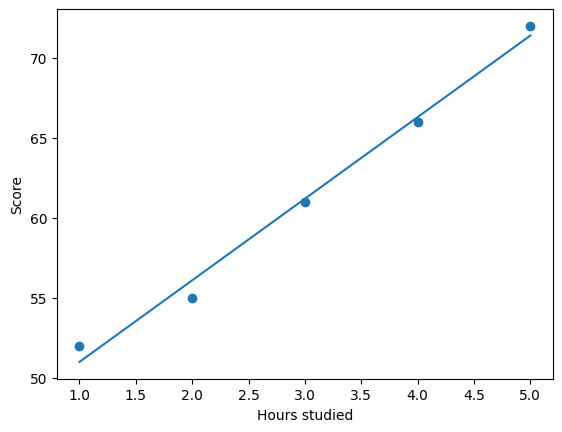

In [220]:
import matplotlib.pyplot as plt

# Create predictions for the existing data
df["prediction"] = model.predict(X)

# Plot the original data
plt.scatter(df["hours_studied"], df["score"])

# Plot the regression line
plt.plot(df["hours_studied"], df["prediction"])

plt.xlabel("Hours studied")
plt.ylabel("Score")
plt.show()